In [18]:
# I want to do a simultaneous evaluation of the POIs and compute the correlation matrix
import uproot
import os
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import mplhep as hep
import seaborn as sns
import ROOT
import pandas as pd
from scipy import stats
import numpy as np
from scipy.optimize import minimize, curve_fit
from scipy.stats import moment
import json
from itertools import combinations  

In [19]:
# Importing translation dictionary
translationFilePath = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/translation.json"
with open(translationFilePath) as translationFile:
    translation = json.load(translationFile)

In [20]:
# Do everything untrimmed, i.e., include failed fits as -999. Then combine every considered variable into a big json file.
# Should we do a trimming??
def pois_untrimmed(toyDir_, poi_list_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    # for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):
    for i in range(len(glob.glob(os.path.join(toyDir_, "bootstrap_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            # current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombineToyFit.MultiDimFit.mH125.root")
            current_root_files = uproot.open(f"{toyDir_}/bootstrap_{i}/higgsCombineBootstrapFit.MultiDimFit.mH125.38.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append(-999.0)
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append(-999.0)
                continue

            pois[current_poi].append(float(current_limit_values[0]))
    return pois

In [21]:
def pois_trimmed(toyDir_, poi_list_, trimming_value_left_, trimming_value_right_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    # for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):
    for i in range(len(glob.glob(os.path.join(toyDir_, "bootstrap_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            # current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombineToyFit.MultiDimFit.mH125.root")
            current_root_files = uproot.open(f"{toyDir_}/bootstrap_{i}/higgsCombineBootstrapFit.MultiDimFit.mH125.38.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        kill_event = False

        # First loop to check if there are outliers (outliers are events smaller than -4 and bigger than 4)
        for j, current_poi in enumerate(poi_list_):
            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append(-999.0)
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if (current_limit_values[0] > trimming_value_right_) or (current_limit_values[0] < trimming_value_left_):
                    kill_event = True 
                    break
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append(-999.0)
                continue

        if kill_event:
            print(f"Skipping fit_{i} with {current_limit_values[0]}: Outlier found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                continue

            pois[current_poi].append(float(current_limit_values[0]))
    return pois

In [22]:
def gaus(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def create_json_trimmed(variable_, toyDir_, pois_untrimmed_, poi_list_, subfolder_, extra_name=""):

    # Now we have to fit a gaussian core to all the categories to get the values where we cut. z is the number of standard deviations we want to cut away
    trimming_value_left = 0
    trimming_value_right = 0
    largest_sigma = 0
    mu_to_largest_sigma = 0
    z = 4 # 4
    for i, current_poi in enumerate(poi_list_):
        r = np.array(pois_untrimmed_[current_poi])
        r = r[r > -998.0]
        mean = np.mean(r)
        s = np.std(r)
        # r = r[r < 5.0]
        
        bins = 30 # 30
        
        counts, bin_edges = np.histogram(r, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        popt, _ = curve_fit(gaus, bin_centers, counts, p0=[1, mean, s], maxfev=10000)
        amp_fit, mu_fit, sigma_fit = popt
        
        # Define the pull
        pull = (r - 1.0) / s
        mean_pull = np.mean(pull)
        s_pull = np.std(pull)
        skewness_pull = stats.skew(pull)
        kurtosis_pull = stats.kurtosis(pull)

        # Fit for the pulls
        counts_pull, bin_edges_pull = np.histogram(pull, bins=bins, density=False)
        bin_centers_pull = (bin_edges_pull[:-1] + bin_edges_pull[1:]) / 2

        popt_pull, _ = curve_fit(gaus, bin_centers_pull, counts_pull, p0=[1, 0.0, 1], maxfev=10000)
        amp_fit_pull, mu_fit_pull, sigma_fit_pull = popt_pull

        if i == 0:
            largest_sigma = sigma_fit
            mu_to_largest_sigma = mu_fit
        else:
            if (sigma_fit > largest_sigma):
                largest_sigma = sigma_fit
                mu_to_largest_sigma = mu_fit

        if (not os.path.exists(f"./Plots/{variable_}/{subfolder_}")) & (f"./Plots/{variable_}/{subfolder_}"!=""):
            os.makedirs(f"./Plots/{variable_}/{subfolder_}")
        

        plt.figure(figsize=(12, 8))
        plt.style.use(hep.style.CMS)
        hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
        plt.hist(r, bins=bins, density=False, alpha=0.6, label='S+B Toys') #30
        plt.plot(bin_centers, gaus(bin_centers, *popt), color='red', label='Fitted Gaussian')
        plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f} ± {s:.2f}')
        plt.axvline(np.median(r), color='blue', linestyle='--', label=f'Median: {np.median(r):.2f}')
        plt.axvline(1.0, color='grey', linestyle='--', label=r'$\mu=1$')
        plt.legend()
        plt.xlabel(f"{translation[f'{current_poi}']}")
        plt.ylabel(r'$N$')
        plt.savefig(f"./Plots/{variable_}/{subfolder_}/gaussian_fit_{current_poi}.png")
        plt.close()

        # Compute the pull
        plt.figure(figsize=(12, 8))

        # Get axis limits
        xlim = plt.xlim()
        ylim = plt.ylim()

        plt.style.use(hep.style.CMS)
        hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
        plt.hist(pull, bins=bins, density=False, alpha=0.6, label='Pull') #30
        plt.plot(bin_centers_pull, gaus(bin_centers_pull, *popt_pull), color='red', label='Fitted Gaussian')
        plt.text(
            xlim[0] + 0.9*(xlim[1] - xlim[0]),   # 70% across the x-axis
            ylim[0] + 0.8*(ylim[1] - ylim[0]),   # 80% up the y-axis
            f'Mean: {mean_pull:.2f}\nStd Dev: {s_pull:.2f}\nSkewness: {skewness_pull:.2f}\nKurtosis: {kurtosis_pull:.2f}',
            bbox=dict(facecolor='white', alpha=0.5)
        )
        plt.xlabel(f"{translation[f'{current_poi}']}")
        plt.ylabel(r'$N$')
        plt.grid()
        plt.savefig(f"./Plots/{variable_}/{subfolder_}/pull_{current_poi}.png")
        plt.close()

    trimming_value_left = mu_to_largest_sigma - z*largest_sigma
    trimming_value_right = mu_to_largest_sigma + z*largest_sigma

    print("Trimming values: ", trimming_value_left, trimming_value_right)

    if trimming_value_left > trimming_value_right:
        trimming_value_left, trimming_value_right = trimming_value_right, trimming_value_left

    if not os.path.exists(f'pois_trimmed_{variable_}{extra_name}.json'):
        pois = pois_trimmed(toyDir_, poi_list_, trimming_value_left, trimming_value_right)
        # Save the POIs to a JSON file
        with open(f'pois_trimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'pois_trimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)
    
    return pois

In [23]:
def create_json_untrimmed_per_variable(variable_, toyDir_, poi_list_, extra_name=""):
    # Loop through all fit directories (fit_0, fit_1, etc.)
    if not os.path.exists(f'pois_untrimmed_{variable_}{extra_name}.json'):
        pois = pois_untrimmed(toyDir_, poi_list_)
        # Save the POIs to a JSON file
        with open(f'pois_untrimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'pois_untrimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)

    return pois

In [24]:
plot_dir = "Plots"
os.makedirs(plot_dir, exist_ok=True)
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_06_12/intermediateRun3/finalfits'
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_10_14_intermediate/finalfits_postBPix'
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_22/earlyRun3_powheg/finalfits'
sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_16/earlyRun3/finalfits'

In [25]:
# Load PTH toys
variable = "PTH"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0", "r_PTH_350p0_10000p0"]
# poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0"]


pois_untrimmed_PTH = create_json_untrimmed_per_variable(variable, toyDir, poi_list)
pois_PTH = create_json_trimmed(variable, toyDir, pois_untrimmed_PTH, poi_list, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_PTH, poi_list, variable)

Trimming values:  -0.2869452894504838 3.609712239945316


In [26]:
# Load NJ toys
variable = "NJ"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_NJ = ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_100p0"]

pois_untrimmed_NJ = create_json_untrimmed_per_variable(variable, toyDir, poi_list_NJ)
pois_NJ = create_json_trimmed(variable, toyDir, pois_untrimmed_NJ, poi_list_NJ, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_untrimmed_NJ, poi_list_NJ, variable)

Trimming values:  -2.2625865862319543 3.9007698902838905


In [27]:
# Load rapidity toys
variable = "rapidity"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_rapidity = ["r_YH_0p0_0p15", "r_YH_0p15_0p3", "r_YH_0p3_0p6", "r_YH_0p6_0p9", "r_YH_0p9_2p5"]

pois_untrimmed_rapidity = create_json_untrimmed_per_variable(variable, toyDir, poi_list_rapidity)
pois_rapidity = create_json_trimmed(variable, toyDir, pois_untrimmed_rapidity, poi_list_rapidity, subfolder_=f"SL_{variable}")

Processing fit_0
Empty ROOT file for bootstrap:  13
Empty ROOT file for bootstrap:  14
Empty ROOT file for bootstrap:  40
Empty ROOT file for bootstrap:  58
Empty ROOT file for bootstrap:  68
Empty ROOT file for bootstrap:  69
Processing fit_100
Empty ROOT file for bootstrap:  103
Empty ROOT file for bootstrap:  104
Empty ROOT file for bootstrap:  106
Empty ROOT file for bootstrap:  108
Empty ROOT file for bootstrap:  114
Empty ROOT file for bootstrap:  116
Empty ROOT file for bootstrap:  120
Empty ROOT file for bootstrap:  135
Empty ROOT file for bootstrap:  138
Empty ROOT file for bootstrap:  143
Empty ROOT file for bootstrap:  148
Empty ROOT file for bootstrap:  194
Empty ROOT file for bootstrap:  196
Processing fit_200
Empty ROOT file for bootstrap:  202
Empty ROOT file for bootstrap:  215
Empty ROOT file for bootstrap:  227
Empty ROOT file for bootstrap:  231
Empty ROOT file for bootstrap:  275
Empty ROOT file for bootstrap:  277
Empty ROOT file for bootstrap:  280
Empty ROOT file

In [38]:
# Load PTJ0 toys
variable = "PTJ0"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_PTJ0 = ["r_PTJ0_0p0_30p0", "r_PTJ0_30p0_75p0", "r_PTJ0_75p0_120p0", "r_PTJ0_120p0_200p0", "r_PTJ0_200p0_10000p0"]

pois_untrimmed_PTJ0 = create_json_untrimmed_per_variable(variable, toyDir, poi_list_PTJ0)
pois_PTJ0 = create_json_trimmed(variable, toyDir, pois_untrimmed_PTJ0, poi_list_PTJ0, subfolder_=f"SL_{variable}")

Processing fit_0
Empty ROOT file for bootstrap:  36
Empty ROOT file for bootstrap:  45
Empty ROOT file for bootstrap:  77
Processing fit_100
Empty ROOT file for bootstrap:  122
Empty ROOT file for bootstrap:  142
Empty ROOT file for bootstrap:  167
Processing fit_200
Empty ROOT file for bootstrap:  230
Processing fit_300
Empty ROOT file for bootstrap:  301
Empty ROOT file for bootstrap:  314
Empty ROOT file for bootstrap:  361
Empty ROOT file for bootstrap:  370
Empty ROOT file for bootstrap:  378
Processing fit_400
Empty ROOT file for bootstrap:  433
Processing fit_500
Skipping fit_584: Required scan files not found
Processing fit_600
Skipping fit_695: Required scan files not found
Empty ROOT file for bootstrap:  699
Processing fit_700
Empty ROOT file for bootstrap:  710
Empty ROOT file for bootstrap:  737
Empty ROOT file for bootstrap:  753
Processing fit_800
Empty ROOT file for bootstrap:  802
Empty ROOT file for bootstrap:  807
Empty ROOT file for bootstrap:  860
Empty ROOT file fo

In [ ]:
# Load DPhiJ0J1 toys
variable = "DPhiJ0J1"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_DPhiJ0J1 = ["r_DPhiJ0J1_m3p1416_m2p0944", "r_DPhiJ0J1_m2p0944_m1p0472", "r_DPhiJ0J1_m1p0472_0p0", "r_DPhiJ0J1_0p0_1p0472", "r_DPhiJ0J1_1p0472_2p0944", "r_DPhiJ0J1_2p0944_3p1416"]

pois_untrimmed_DPhiJ0J1 = create_json_untrimmed_per_variable(variable, toyDir, poi_list_DPhiJ0J1)
pois_DPhiJ0J1 = create_json_trimmed(variable, toyDir, pois_untrimmed_DPhiJ0J1, poi_list_DPhiJ0J1, subfolder_=f"SL_{variable}")

Processing fit_0
Value out of boundary -4.1990757 44
Empty ROOT file for bootstrap:  45
Empty ROOT file for bootstrap:  68
Value out of boundary -5.395381 69


In [40]:
df_PTH = pd.DataFrame(pois_PTH)
df_NJ = pd.DataFrame(pois_NJ)
df_PTJ0 = pd.DataFrame(pois_PTJ0)
df_DPhiJ0J1 = pd.DataFrame(pois_DPhiJ0J1)
df_rapidity = pd.DataFrame(pois_rapidity)


In [11]:
df_PTH_untrimmed = pd.DataFrame(pois_untrimmed_PTH)
df_NJ_untrimmed = pd.DataFrame(pois_untrimmed_NJ)
mask_pth_untrimmed = (df_PTH_untrimmed != -999).all(axis=1)
mask_nj_untrimmed = (df_NJ_untrimmed != -999).all(axis=1)
valid_rows_untrimmed = mask_pth_untrimmed & mask_nj_untrimmed
df_PTH_clean_untrimmed = df_PTH_untrimmed[valid_rows_untrimmed]
df_NJ_clean_untrimmed = df_NJ_untrimmed[valid_rows_untrimmed]

In [41]:

# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# # Mask for df_PTH (True = valid, False = -999)
mask_pth = (df_PTH != -999).all(axis=1) 

# # Mask for df_NJ (True = valid, False = -999)
mask_nj = (df_NJ != -999).all(axis=1)

# # Mask for df_PTJ0 (True = valid, False = -999)
mask_ptj0 = (df_PTJ0 != -999).all(axis=1)

# # Mask for df_DPhiJ0J1 (True = valid, False = -999)
mask_DPhiJ0J1 = (df_DPhiJ0J1 != -999).all(axis=1)

# # Mask for df_rapidity (True = valid, False = -999)
mask_rapidity = (df_rapidity != -999).all(axis=1)

# Combined mask (keep only rows valid in BOTH DataFrames)
valid_rows = mask_pth & mask_nj & mask_ptj0 & mask_DPhiJ0J1 & mask_rapidity
# valid_rows = mask_pth & mask_nj & mask_rapidity

# --- Step 2: Filter DataFrames ---
df_PTH_clean = df_PTH[valid_rows]
df_NJ_clean = df_NJ[valid_rows]
df_PTJ0_clean = df_PTJ0[valid_rows]
df_DPhiJ0J1_clean = df_DPhiJ0J1[valid_rows]
df_rapidity_clean = df_rapidity[valid_rows]

# --- Step 3: Compute Correlation Matrix ---
# Combine columns (now aligned and cleaned)
df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_PTJ0_clean, df_rapidity_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_NJ_clean, df_rapidity_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_PTJ0_clean, df_NJ_clean], axis=1)


# Calculate full correlation matrix
# mask = df_combined["r_PTH_45p0_80p0"] > 2
# corr_matrix = df_combined[mask].corr()
corr_matrix = df_combined.corr()

# # Extract cross-correlations (PTH vs. NJ bins)
# pth_cols = df_PTH.columns
# nj_cols = df_NJ.columns
# ptj0_cols = df_PTJ0.columns
# print(ptj0_cols)
# cross_corr = corr_matrix.loc[pth_cols, nj_cols, ptj0_cols]

# print("Correlation Matrix (Excluding Rows with -999):")
# print(cross_corr)

df_combined

/tmp/ipykernel_2519311/99195816.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_PTJ0_clean = df_PTJ0[valid_rows]


,r_PTH_0p0_15p0,r_PTH_15p0_30p0,r_PTH_30p0_45p0,r_PTH_45p0_80p0,r_PTH_80p0_120p0,r_PTH_120p0_200p0,r_PTH_200p0_350p0,r_PTH_350p0_10000p0,r_DPhiJ0J1_m3p1416_m2p0944,r_DPhiJ0J1_m2p0944_m1p0472,...,r_PTJ0_0p0_30p0,r_PTJ0_30p0_75p0,r_PTJ0_75p0_120p0,r_PTJ0_120p0_200p0,r_PTJ0_200p0_10000p0,r_YH_0p0_0p15,r_YH_0p15_0p3,r_YH_0p3_0p6,r_YH_0p6_0p9,r_YH_0p9_2p5
0,0.932272,1.294229,1.831626,1.435926,0.407468,2.072674,0.335692,-0.013463,1.721797,6.555366,...,0.909049,1.515510,1.980301,1.342402,-0.786948,1.614426,2.408469,1.651220,1.766027,0.764097
1,0.791452,1.546120,1.965186,1.032743,0.880023,1.251404,0.667603,0.334226,-2.386744,2.950477,...,1.425231,1.235917,1.037248,-0.420502,-0.433259,1.829669,2.063324,1.650775,0.941592,0.712325
4,0.525900,0.933291,2.880022,0.989266,1.000431,1.192318,0.675010,-0.230720,-0.612376,3.629015,...,0.946114,1.810569,1.400828,0.914755,-0.144887,1.509552,1.917434,0.772006,2.083985,0.706835
5,0.989262,0.865907,0.996478,1.194350,0.040177,1.760615,0.482089,-0.050893,1.179138,0.659611,...,0.748578,1.378440,1.607705,0.300843,0.795841,1.282445,1.470253,0.846168,0.984654,0.625878
6,1.500504,1.381819,1.714641,0.750840,0.709005,1.376263,0.569511,-0.246103,-1.173286,4.018107,...,1.121670,0.721301,1.777155,1.644803,0.510201,1.166436,2.603040,0.794105,0.848236,0.845516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3019,1.743322,1.064547,1.889842,0.939389,0.404224,1.605888,0.926538,0.159161,-1.605294,4.790831,...,1.620239,1.146466,0.338275,1.473045,1.049202,2.056267,1.931482,0.890593,1.010682,1.027289
3020,1.376649,0.750787,1.234029,1.305230,0.979257,1.558810,0.134804,0.274295,0.257171,2.887904,...,0.947570,1.580900,1.063505,0.935585,0.234074,1.628005,1.619873,0.509965,2.057876,0.335109
3024,1.220371,1.915017,2.084156,1.601617,0.474079,1.320076,0.945306,0.010379,1.596869,0.684420,...,1.761448,1.018961,3.076349,1.942637,-1.002563,1.640050,3.615244,1.262380,1.522067,0.730055
3025,1.497761,2.130222,1.840617,1.130253,0.364595,1.841051,0.813652,-0.186427,0.198393,1.247694,...,1.774990,0.875670,2.516028,1.144272,0.694916,1.397118,3.034752,0.478679,1.864152,2.480579


1182


NameError: name 'mask' is not defined

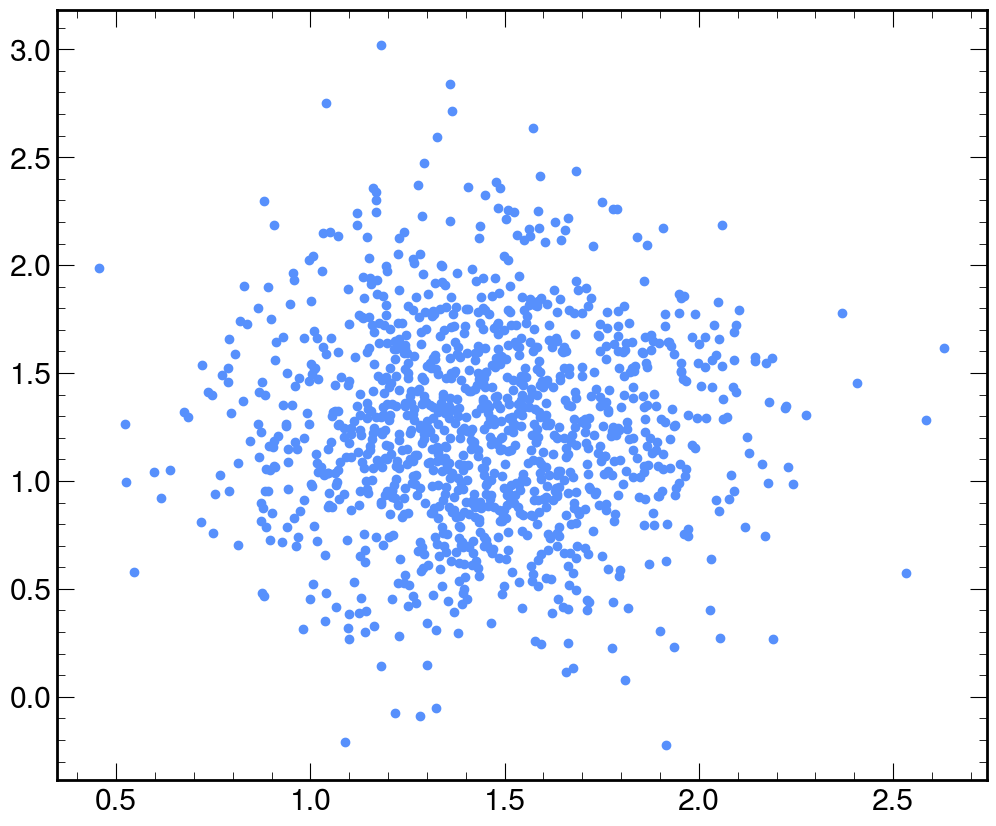

In [42]:

# mask = ~mask
print((df_PTH_clean["r_PTH_45p0_80p0"] < 2).sum())

plt.figure(figsize=(12, 10))
plt.scatter(x=df_PTH_clean["r_PTH_120p0_200p0"], y=df_PTH_clean["r_PTH_15p0_30p0"])
# plt.xlim(0.995,1.005)
# plt.ylim(0.98,1.02)

# plt.xlabel(translation["r_PTH_200p0_350p0"])
# plt.ylabel(translation["r_PTH_45p0_80p0"])
# plt.show()



print(df_PTH_clean[mask]["r_PTH_120p0_200p0"].corr(df_PTH_clean[mask]["r_PTH_15p0_30p0"]))
# print(df_PTH_clean["r_PTH_120p0_200p0"].corr(df_PTH_clean["r_PTH_15p0_30p0"]))


In [43]:
# 1️⃣ Define your stops and RGB values
stops = [0.0, 0.5, 1.0]
red   = [0.992, 1.0, 0.110]
green = [0.749, 1.0, 0.196]
blue  = [0.106, 1.0, 0.867]

# 2️⃣ Build the color dictionary
cdict = {
    'red':   [(stops[i], red[i], red[i]) for i in range(len(stops))],
    'green': [(stops[i], green[i], green[i]) for i in range(len(stops))],
    'blue':  [(stops[i], blue[i], blue[i]) for i in range(len(stops))]
}

# 3️⃣ Create the colormap
custom_cmap = LinearSegmentedColormap('gradient_8289', cdict)

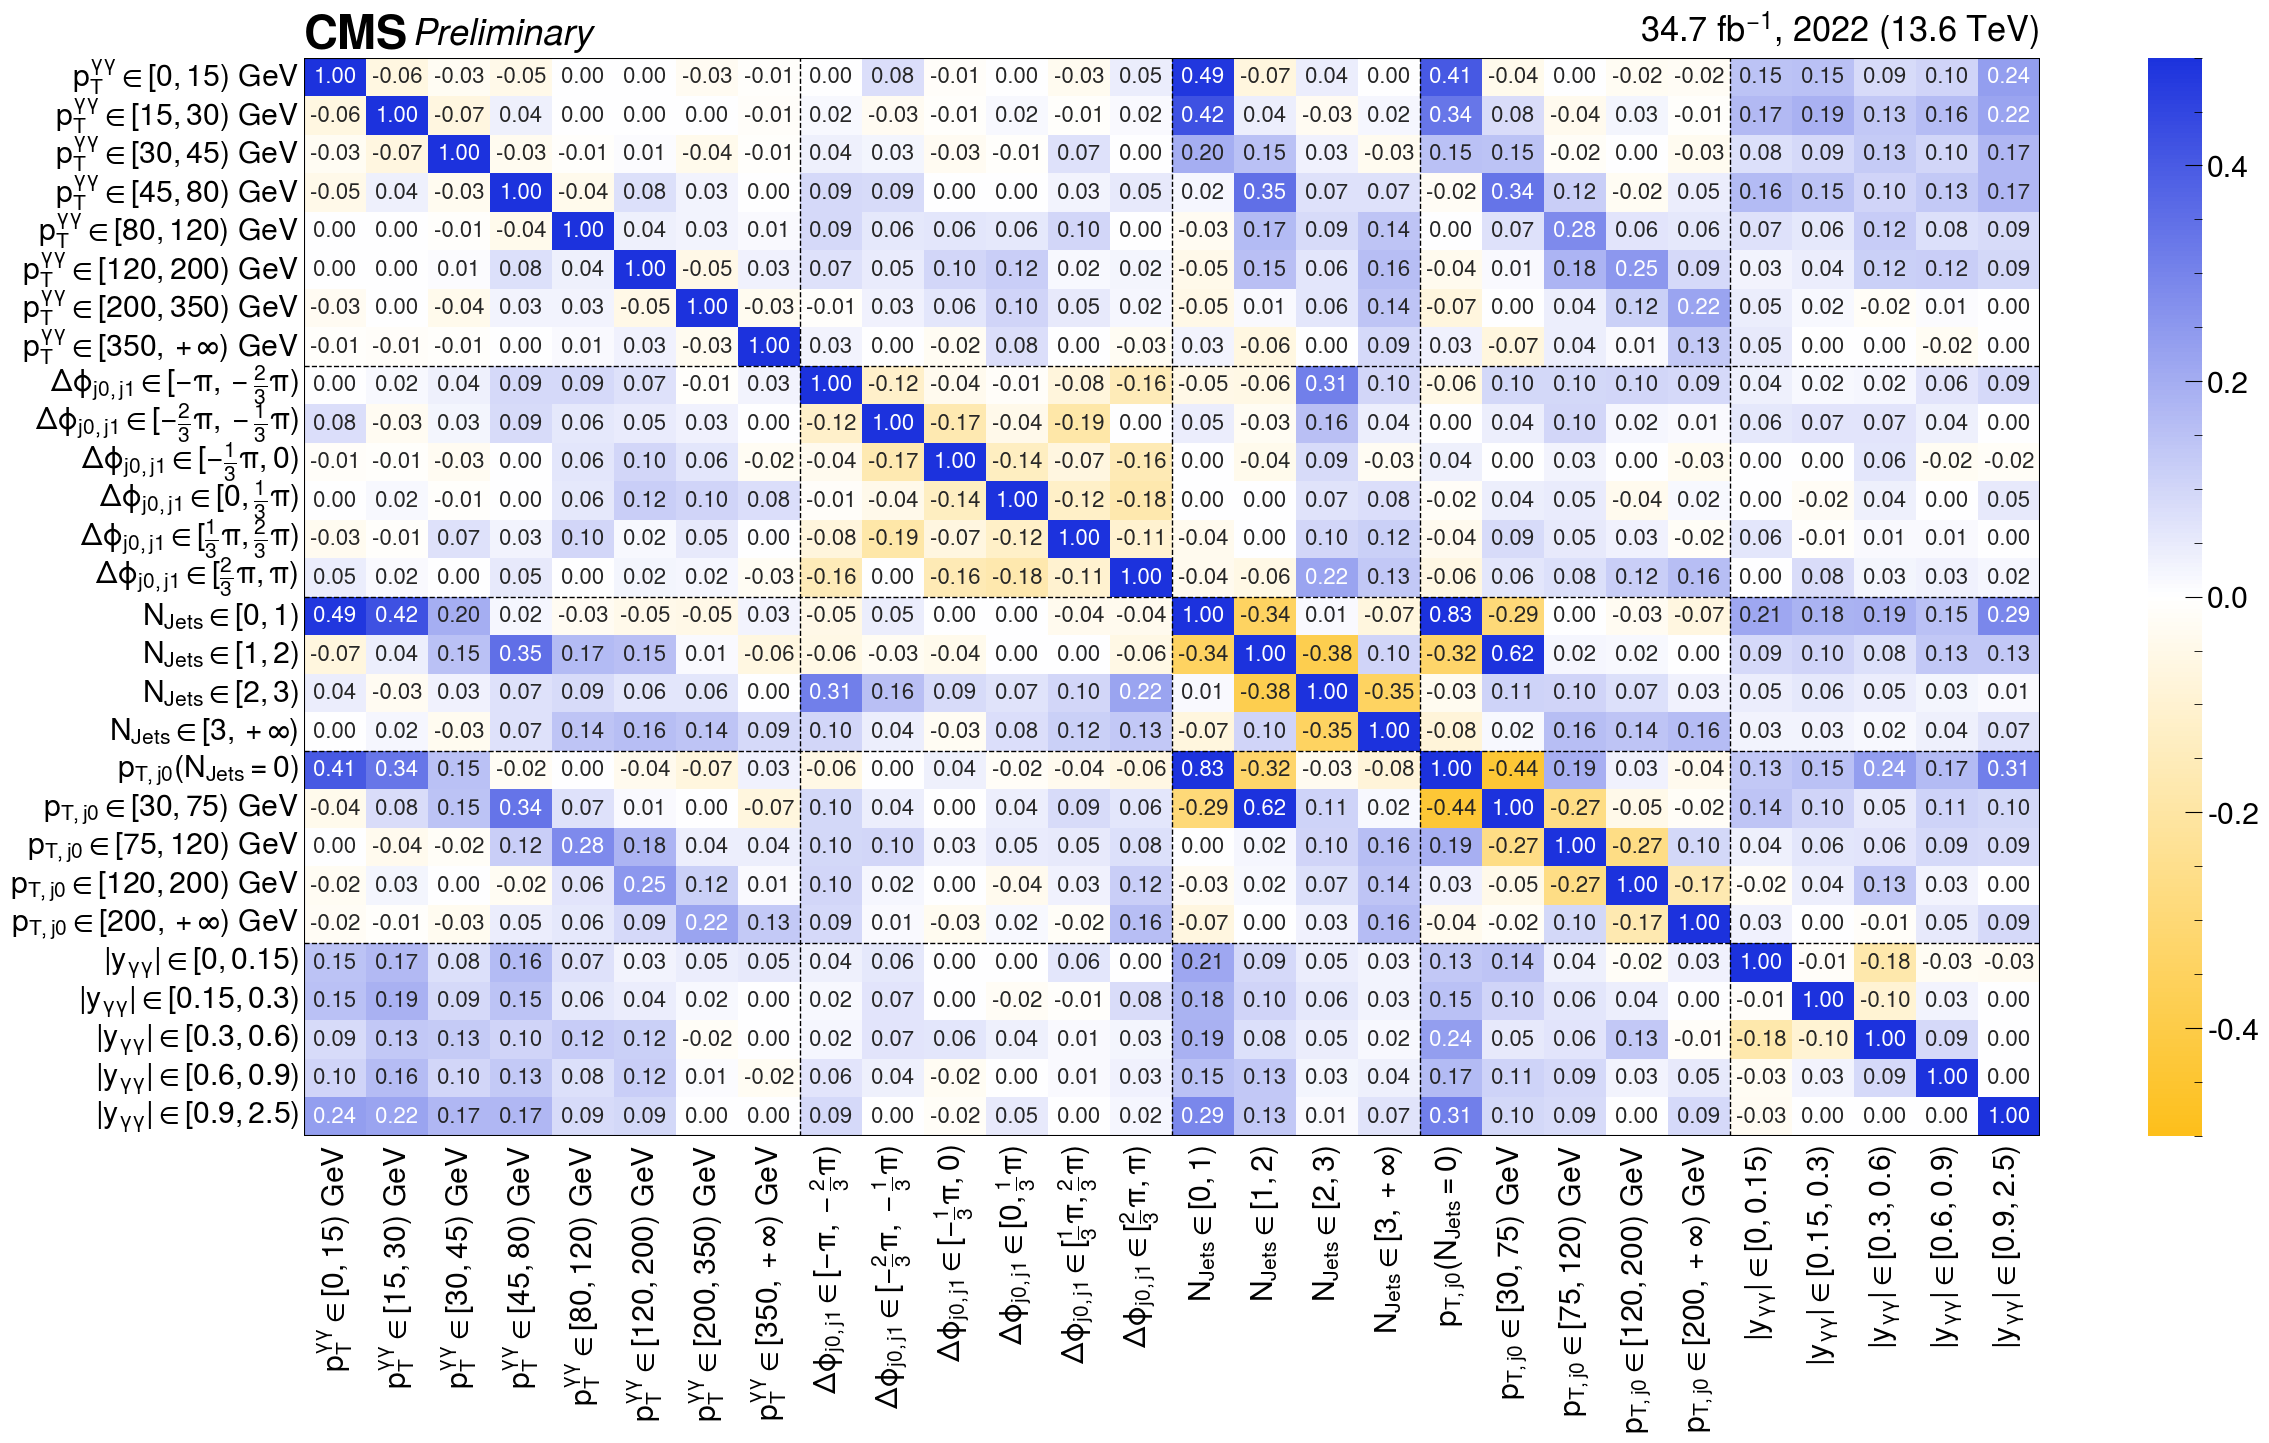

In [45]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=True, lumi=34.7, com=13.6, year=2022)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 14, 18, 23]  # Example indices between variable blocks # 8, 12, 17, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join(plot_dir, "correlation_matrix_obs.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix_obs.png"), bbox_inches='tight')

# plt.close()


In [53]:
# Try applying the third moments 

def calc_abc_dict(pois):
    # First, calculate the third moments for each POI
    cov_matrix = np.cov([np.array(pois[current_poi_])[np.array(pois[current_poi_]) > -998.0] for current_poi_ in list(pois.keys())])
    abc_dict = {}
    for i, current_poi in enumerate(pois.keys()):
        # print(i, current_poi)
        r = np.array(pois[current_poi])
        r = r[r > -998.0]
        m_one = np.mean(r)
        m_two = cov_matrix[i][i]
        m_three = np.mean((r - m_one)**3)
        
        c_i = -np.sign(m_three) * np.sqrt(2 * m_two) * np.cos(((4* np.pi) / 3) + ((1/3) * np.arctan(np.sqrt((8 * (m_two**3 / m_three**2)) - 1))))
        b_i = np.sqrt(m_two - 2*(c_i**2))
        a_i = m_one - c_i
        abc_dict[current_poi] = (a_i, b_i, c_i)
    return abc_dict
        

In [54]:
def calc_SL_rho(pois, abc_dict_):
    cov_matrix = np.cov([np.array(pois[current_poi_])[np.array(pois[current_poi_]) > -998.0] for current_poi_ in pois.keys()])
    poi_names = list(pois.keys())
    rho = []
    for i, current_poi in enumerate(pois.keys()):
        a_i, b_i, c_i = abc_dict_[current_poi]
        rho_i = []
        for j, other_poi in enumerate(pois.keys()):
            a_j, b_j, c_j = abc_dict_[other_poi]
            m_two_ij = cov_matrix[i][j]
            
            rho_ij = (1/(4*c_i*c_j)) * (np.sqrt((b_i**2 * b_j**2) + 8*(c_i*c_j*m_two_ij)) - (b_i * b_j))
            rho_i.append(rho_ij)
        rho.append(rho_i)
        
    rho_df = pd.DataFrame(rho, index=poi_names, columns=poi_names)
    return rho_df


In [55]:
# Extend the pois to multplie variables
# combined_pois = {}
# for current_poi in poi_list:
#     combined_pois[current_poi] = pois_PTH[current_poi]
# for current_poi in poi_list_NJ:
#     combined_pois[current_poi] = pois_NJ[current_poi]

# combined_pois.keys()

combined_pois = df_combined.to_dict(orient='list')

In [56]:
abc_dict = calc_abc_dict(combined_pois)
corr_matrix = calc_SL_rho(combined_pois, abc_dict)

In [57]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 12, 17, 23]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join(plot_dir, "correlation_matrix_abc.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix_abc.png"), bbox_inches='tight')
plt.show()

In [58]:
z_hat = 0.5 * np.log((1 + corr_matrix) / (1 - corr_matrix)) + (corr_matrix / (2*(len(df_combined) - 2)))
a = np.tanh(z_hat - np.sqrt(1 / (len(df_combined) - 3)))
b = np.tanh(z_hat + np.sqrt(1 / (len(df_combined) - 3)))

In [59]:
# From Wikipedia https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
import numpy as np
t_values = np.sqrt((1 - corr_matrix**2) / (len(df_combined) - 2))
np.fill_diagonal(t_values.values, 0)
sigma = t_values.max().max()

In [60]:
sigma